In [1]:
!pip install librosa
!pip install soundfile
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tqdm
!pip install torch torchvision torchaudio
!pip install opensmile

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------------------

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [3]:
VOICE_PATH = r"D:\ML-PROJECTS\Emotion analysis\dataset\voice-Mozilla\cv-valid-train\cv-valid-train"
RAVDESS_PATH = r"D:\ML-PROJECTS\Emotion analysis\dataset\RAVDESS"

In [4]:
print("Dataset Exists :", os.path.exists(VOICE_PATH))

files = os.listdir(VOICE_PATH)

print("Total Files :", len(files))

print("\nFirst 10 Files")

files[:10]

Dataset Exists : True
Total Files : 195776

First 10 Files


['sample-000000.mp3',
 'sample-000001.mp3',
 'sample-000002.mp3',
 'sample-000003.mp3',
 'sample-000004.mp3',
 'sample-000005.mp3',
 'sample-000006.mp3',
 'sample-000007.mp3',
 'sample-000008.mp3',
 'sample-000009.mp3']

In [5]:
for file in os.listdir(VOICE_PATH):
    if file.endswith(".csv") or file.endswith(".tsv"):
        print(file)

In [6]:
audio_files = [f for f in files if f.endswith(".mp3")]

print("Total Audio Files:", len(audio_files))

print(audio_files[:5])

Total Audio Files: 195776
['sample-000000.mp3', 'sample-000001.mp3', 'sample-000002.mp3', 'sample-000003.mp3', 'sample-000004.mp3']


In [7]:
sample_path = os.path.join(VOICE_PATH, audio_files[0])

signal, sr = librosa.load(sample_path, sr=16000)

print("Sampling Rate :", sr)
print("Audio Length :", len(signal))

Sampling Rate : 16000
Audio Length : 65664


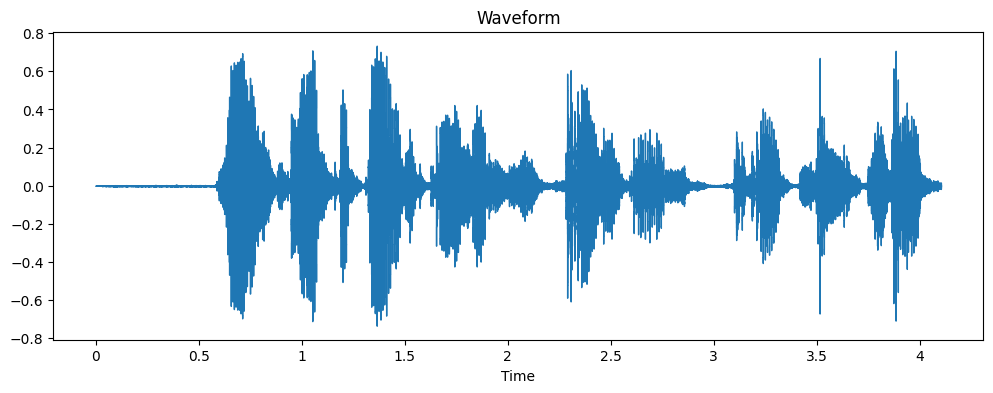

In [8]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(signal, sr=sr)

plt.title("Waveform")

plt.show()

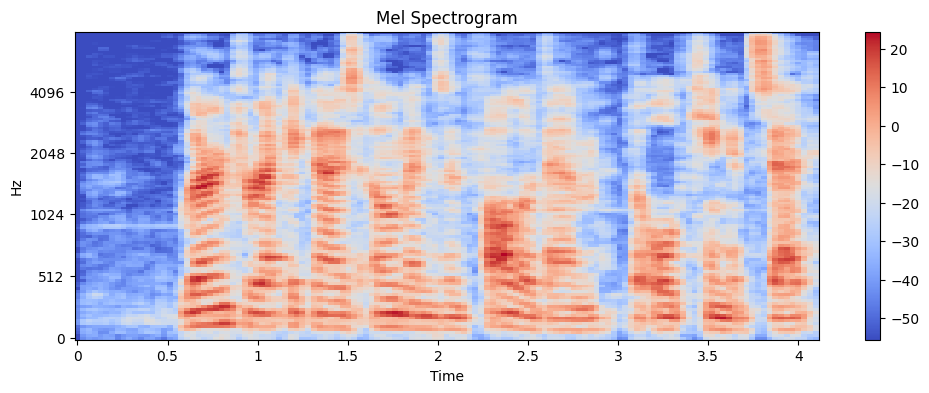

In [9]:
spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr
)

db = librosa.power_to_db(spec)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

MFCC Shape : (40, 129)


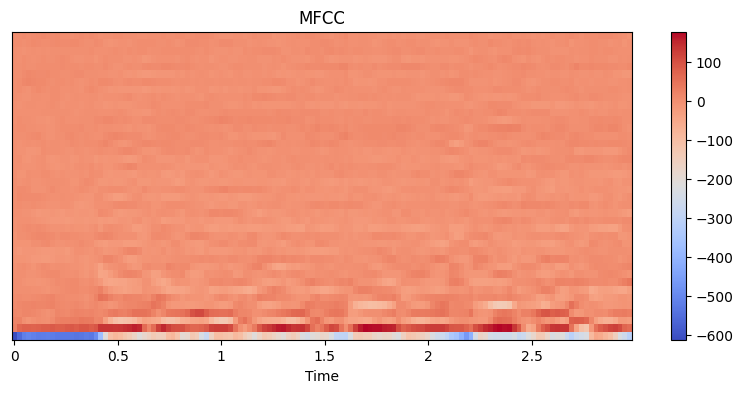

In [26]:
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=40
)

print("MFCC Shape :", mfcc.shape)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC")

plt.show()

In [10]:
import pandas as pd

CSV_PATH = r"D:\ML-PROJECTS\Emotion analysis\dataset\voice-Mozilla\cv-valid-train.csv"

df = pd.read_csv(CSV_PATH)

print(df.shape)

df.head()

(195776, 8)


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000000.mp3,learn to recognize omens and follow them the o...,1,0,NaN,NaN,NaN,NaN
1,cv-valid-train/sample-000001.mp3,everything in the universe evolved he said,1,0,NaN,NaN,NaN,NaN
2,cv-valid-train/sample-000002.mp3,you came so that you could learn about your dr...,1,0,NaN,NaN,NaN,NaN
3,cv-valid-train/sample-000003.mp3,so now i fear nothing because it was those ome...,1,0,NaN,NaN,NaN,NaN
4,cv-valid-train/sample-000004.mp3,if you start your emails with greetings let me...,3,2,NaN,NaN,NaN,NaN


In [11]:
print(df.columns)

Index(['filename', 'text', 'up_votes', 'down_votes', 'age', 'gender', 'accent',
       'duration'],
      dtype='str')


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195776 entries, 0 to 195775
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   filename    195776 non-null  str    
 1   text        195776 non-null  str    
 2   up_votes    195776 non-null  int64  
 3   down_votes  195776 non-null  int64  
 4   age         73768 non-null   str    
 5   gender      74059 non-null   str    
 6   accent      64711 non-null   str    
 7   duration    0 non-null       float64
dtypes: float64(1), int64(2), str(5)
memory usage: 28.2 MB


In [13]:
df.isnull().sum()

filename           0
text               0
up_votes           0
down_votes         0
age           122008
gender        121717
accent        131065
duration      195776
dtype: int64

In [14]:
print(df["gender"].value_counts())

gender
male      55029
female    18249
other       781
Name: count, dtype: int64


In [15]:
print(df["age"].value_counts())

age
twenties     23003
thirties     18303
fourties     11100
fifties       9466
teens         5441
sixties       4584
seventies     1632
eighties       239
Name: count, dtype: int64


In [18]:
print("Total Samples :", len(df))

print("\nGender Labels")
print(df["gender"].value_counts(dropna=False))

print("\nAge Labels")
print(df["age"].value_counts(dropna=False))

Total Samples : 195776

Gender Labels
gender
NaN       121717
male       55029
female     18249
other        781
Name: count, dtype: int64

Age Labels
age
NaN          122008
twenties      23003
thirties      18303
fourties      11100
fifties        9466
teens          5441
sixties        4584
seventies      1632
eighties        239
Name: count, dtype: int64


In [19]:
valid_df = df.dropna(subset=["gender", "age"])

print("Total Valid Samples :", len(valid_df))

valid_df.head()

Total Valid Samples : 73466


,filename,text,up_votes,down_votes,age,gender,accent,duration
5,cv-valid-train/sample-000005.mp3,a shepherd may like to travel but he should ne...,1,0,twenties,female,us,NaN
8,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,seventies,male,us,NaN
13,cv-valid-train/sample-000013.mp3,but he had found a guide and didn't want to mi...,1,0,thirties,female,us,NaN
14,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,sixties,male,england,NaN
19,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,fifties,male,australia,NaN


In [20]:
valid_df.to_csv(
    "valid_metadata.csv",
    index=False
)

print(valid_df.shape)

(73466, 8)


In [37]:
print(valid_df["gender"].value_counts())

print()

print(valid_df["age"].value_counts())

gender
male      54593
female    18099
other       774
Name: count, dtype: int64

age
twenties     22927
thirties     18287
fourties     10914
fifties       9442
teens         5441
sixties       4584
seventies     1632
eighties       239
Name: count, dtype: int64


In [21]:
df["gender"].value_counts(dropna=False)

gender
NaN       121717
male       55029
female     18249
other        781
Name: count, dtype: int64

In [22]:
df["age"].value_counts(dropna=False)

age
NaN          122008
twenties      23003
thirties      18303
fourties      11100
fifties        9466
teens          5441
sixties        4584
seventies      1632
eighties        239
Name: count, dtype: int64

In [23]:
print(valid_df.shape)

(73466, 8)


In [24]:
male_df = valid_df[valid_df["gender"] == "male"].copy()

print("Male Samples:", len(male_df))

male_df.head()

Male Samples: 54593


,filename,text,up_votes,down_votes,age,gender,accent,duration
8,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,seventies,male,us,NaN
14,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,sixties,male,england,NaN
19,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,fifties,male,australia,NaN
20,cv-valid-train/sample-000020.mp3,it was faintly marked with transverse stripes ...,5,1,thirties,male,england,NaN
23,cv-valid-train/sample-000023.mp3,i had seen all that it would presently bring me,5,0,thirties,male,us,NaN


In [25]:
age_mapping = {
    "teens": 16,
    "twenties": 25,
    "thirties": 35,
    "fourties": 45,
    "fifties": 55,
    "sixties": 65,
    "seventies": 75,
    "eighties": 85
}

male_df["age"] = male_df["age"].map(age_mapping)

male_df.head()

,filename,text,up_votes,down_votes,age,gender,accent,duration
8,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,75,male,us,NaN
14,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,65,male,england,NaN
19,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,55,male,australia,NaN
20,cv-valid-train/sample-000020.mp3,it was faintly marked with transverse stripes ...,5,1,35,male,england,NaN
23,cv-valid-train/sample-000023.mp3,i had seen all that it would presently bring me,5,0,35,male,us,NaN


In [26]:
print(male_df["age"].value_counts().sort_index())

age
16     4249
25    18494
35    13662
45     8684
55     4946
65     2835
75     1502
85      221
Name: count, dtype: int64


In [27]:
male_df["senior"] = male_df["age"].apply(lambda x: 1 if x > 60 else 0)

male_df.head()

,filename,text,up_votes,down_votes,age,gender,accent,duration,senior
8,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,75,male,us,NaN,1
14,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,65,male,england,NaN,1
19,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,55,male,australia,NaN,0
20,cv-valid-train/sample-000020.mp3,it was faintly marked with transverse stripes ...,5,1,35,male,england,NaN,0
23,cv-valid-train/sample-000023.mp3,i had seen all that it would presently bring me,5,0,35,male,us,NaN,0


In [28]:
print(male_df["senior"].value_counts())

senior
0    50035
1     4558
Name: count, dtype: int64


In [39]:
import os

AUDIO_ROOT = r"D:\ML-PROJECTS\Emotion analysis\dataset\voice-Mozilla\cv-valid-train\cv-valid-train"

male_df["filepath"] = male_df["filename"].apply(
    lambda x: os.path.join(AUDIO_ROOT, os.path.basename(x))
)

male_df.head()

,filename,text,up_votes,down_votes,age,gender,accent,duration,senior,filepath,exists
8,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,75,male,us,NaN,1,D:\ML-PROJECTS\Emotion analysis\dataset\voice-...,False
14,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,65,male,england,NaN,1,D:\ML-PROJECTS\Emotion analysis\dataset\voice-...,False
19,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,55,male,australia,NaN,0,D:\ML-PROJECTS\Emotion analysis\dataset\voice-...,False
20,cv-valid-train/sample-000020.mp3,it was faintly marked with transverse stripes ...,5,1,35,male,england,NaN,0,D:\ML-PROJECTS\Emotion analysis\dataset\voice-...,False
23,cv-valid-train/sample-000023.mp3,i had seen all that it would presently bring me,5,0,35,male,us,NaN,0,D:\ML-PROJECTS\Emotion analysis\dataset\voice-...,False


In [40]:
male_df["exists"] = male_df["filepath"].apply(os.path.exists)

print(male_df["exists"].value_counts())

exists
True    54593
Name: count, dtype: int64
